### 1. Generating Synthetic Sleep/Activity Data with Anomalies

I will create a synthetic dataset that simulates a person's activity levels throughout the day. Normal patterns will include low activity during sleep hours and higher activity during wake hours. Anomalies will be introduced as sudden spikes or dips in activity that deviate from these normal patterns.

### 2. Data Preprocessing for LSTM

### 4. Anomaly Detection and Visualization

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Reconstruction error threshold: 0.4101


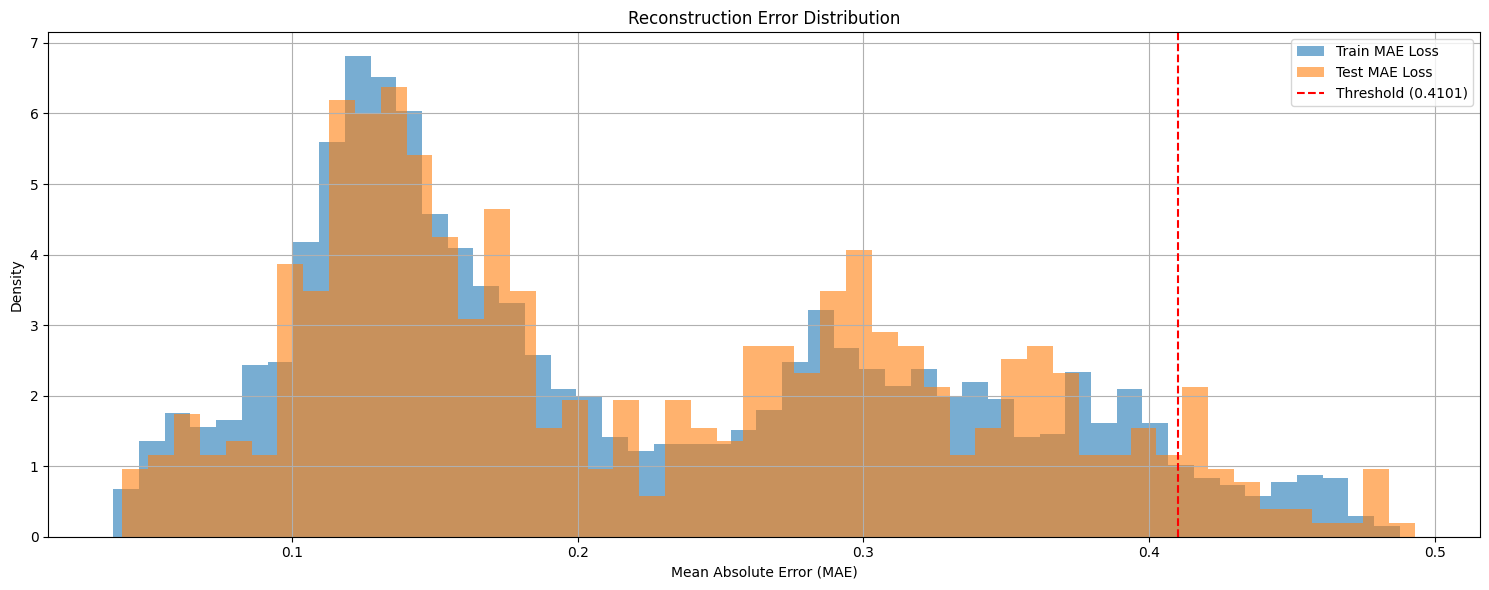

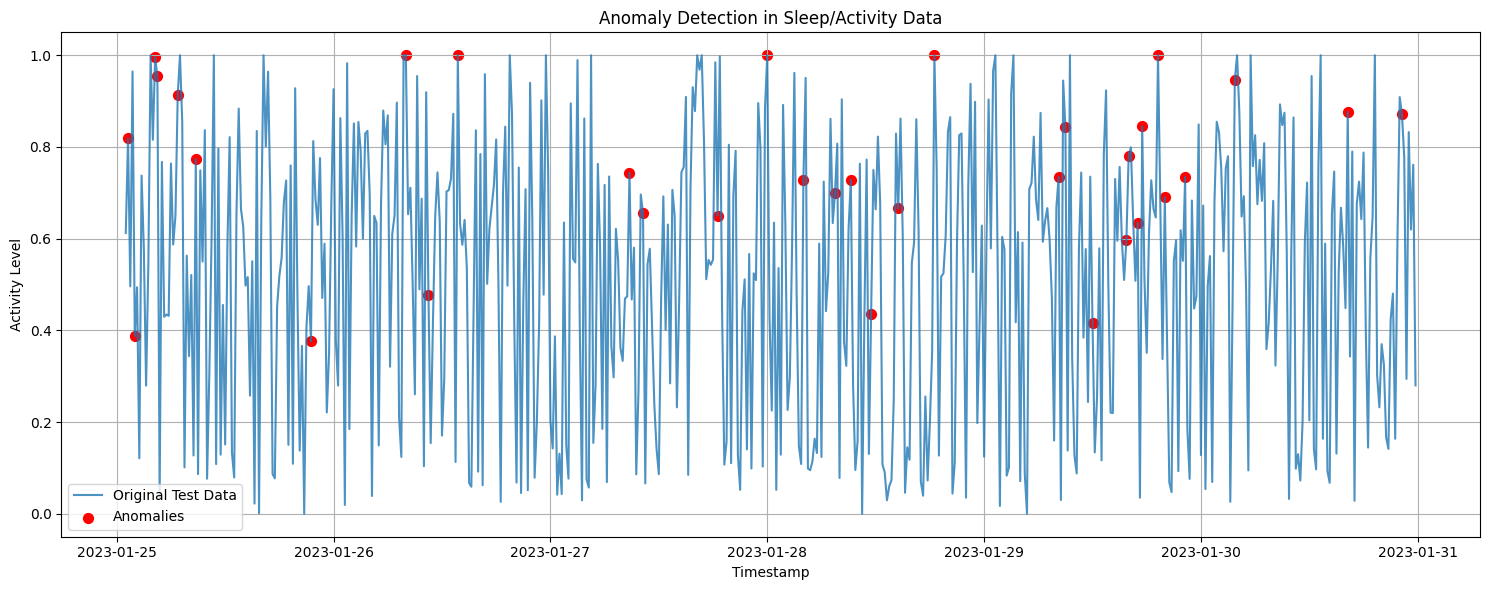

In [ ]:
# Predict on test data
X_train_pred = model.predict(X_train)
X_test_pred = model.predict(X_test)

# Calculate reconstruction error (MAE)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=1).flatten()
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1).flatten()

# Determine anomaly threshold (e.g., based on training data's 95th percentile)
threshold = np.percentile(train_mae_loss, 95)
print(f'Reconstruction error threshold: {threshold:.4f}')

# Identify anomalies in the test set
anomalies = test_mae_loss > threshold

# --- Visualize results ---

# Rescale test data for plotting (using y_test for the actual values)
original_test_data = scaler.inverse_transform(y_test).flatten()

# Plot reconstruction error
plt.figure(figsize=(15, 6))
plt.hist(train_mae_loss, bins=50, density=True, alpha=0.6, label='Train MAE Loss')
plt.hist(test_mae_loss, bins=50, density=True, alpha=0.6, label='Test MAE Loss')
plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Mean Absolute Error (MAE)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot original data with anomalies highlighted
plt.figure(figsize=(15, 6))
plt.plot(df.index[-len(original_test_data):], original_test_data, label='Original Test Data', alpha=0.8)
plt.scatter(df.index[-len(original_test_data):][anomalies],
            original_test_data[anomalies],
            color='r', marker='o', s=50, label='Anomalies')
plt.title('Anomaly Detection in Sleep/Activity Data')
plt.xlabel('Timestamp')
plt.ylabel('Activity Level')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 3. Build and Train the LSTM Autoencoder Model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - loss: 0.2055 - val_loss: 0.1379
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.1276 - val_loss: 0.1195
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.1174 - val_loss: 0.1162
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.1134 - val_loss: 0.1168
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 0.1108 - val_loss: 0.1097
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.1084 - val_loss: 0.1111
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.1076 - val_loss: 0.1086
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.1066 - val_loss: 0.1079
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.1056 - val_loss: 0.1073
Epoch 10/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.1022 - val_loss: 0.1068
Epoch 11/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.1014 - val_loss: 0.1080
Epoch 12/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/s

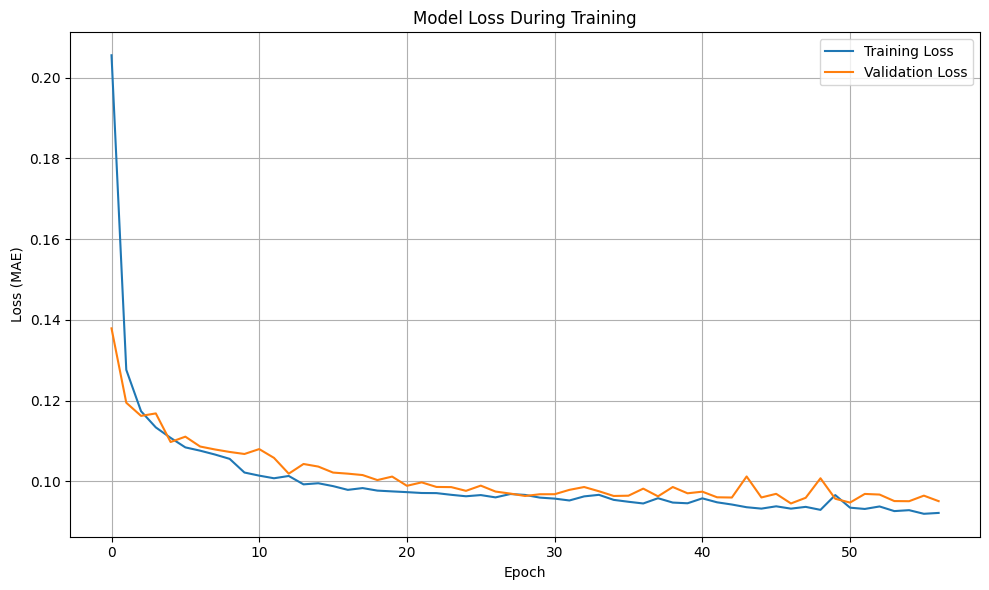

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Define the LSTM Autoencoder model
model = Sequential()
model.add(LSTM(128, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(RepeatVector(X_train.shape[1]))
model.add(LSTM(128, activation='relu', return_sequences=True))
model.add(TimeDistributed(Dense(X_train.shape[2])))

model.compile(optimizer='adam', loss='mae')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_split=0.1, callbacks=[EarlyStopping(monitor='val_loss', patience=10)],
                    shuffle=False)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Normalize the activity data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df['activity'].values.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 24 # Use 24 time steps (6 hours of 15-min intervals) to predict the next step

X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2284, 24, 1)
Shape of y_train: (2284, 1)
Shape of X_test: (572, 24, 1)
Shape of y_test: (572, 1)


                     activity
timestamp                    
2023-01-01 00:00:00  0.124836
2023-01-01 00:15:00  0.093087
2023-01-01 00:30:00  0.132384
2023-01-01 00:45:00  0.176151
2023-01-01 01:00:00  0.088292
                     activity
timestamp                    
2023-01-30 22:45:00  0.227225
2023-01-30 23:00:00  0.225079
2023-01-30 23:15:00  0.246578
2023-01-30 23:30:00  0.323375
2023-01-30 23:45:00  0.285014


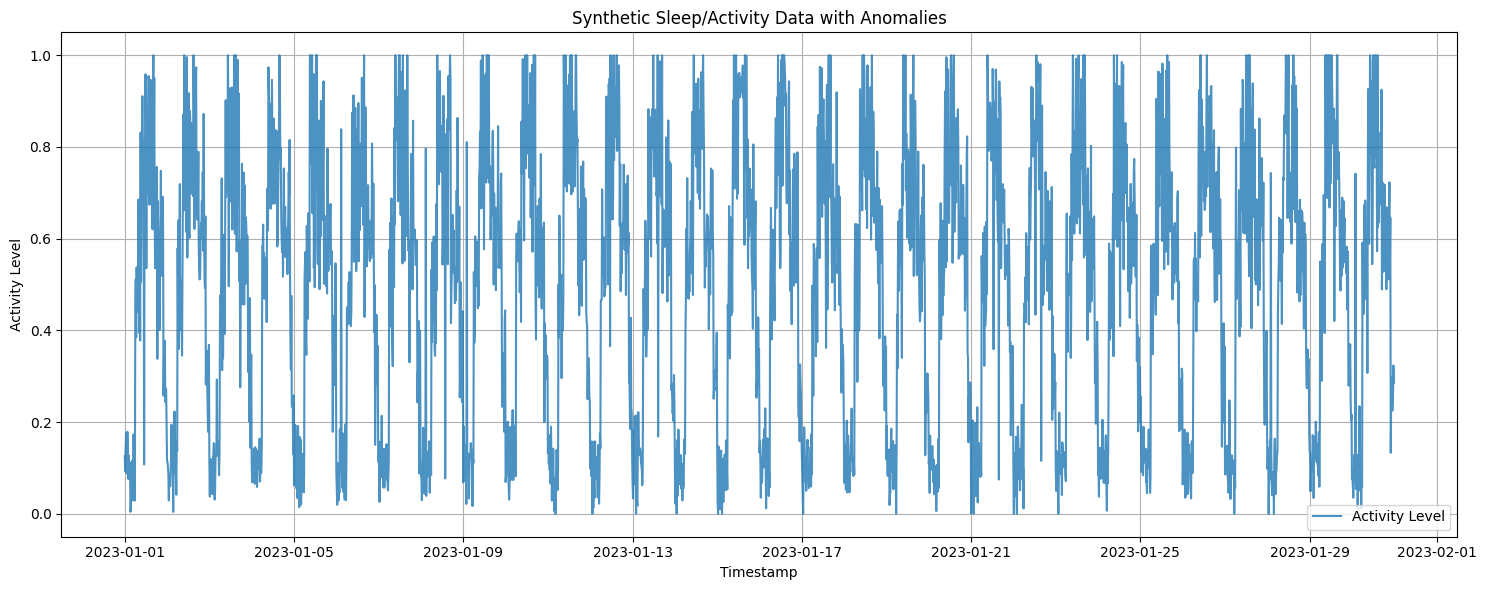

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# --- Generate synthetic data ---
# 30 days of data, sampled every 15 minutes
dates = pd.date_range(start='2023-01-01', periods=30 * 24 * 4, freq='15min')

# Base activity pattern (e.g., low at night, high during the day)
def get_base_activity(hour):
    if 0 <= hour < 6: # Sleep hours
        return np.random.normal(loc=0.1, scale=0.05)
    elif 6 <= hour < 9: # Morning activity
        return np.random.normal(loc=0.5, scale=0.1)
    elif 9 <= hour < 17: # Daytime activity
        return np.random.normal(loc=0.8, scale=0.15)
    elif 17 <= hour < 22: # Evening activity
        return np.random.normal(loc=0.6, scale=0.1)
    else: # Late night activity
        return np.random.normal(loc=0.3, scale=0.08)

activity_levels = [get_base_activity(d.hour) for d in dates]
activity_levels = np.clip(activity_levels, 0, 1) # Clip to ensure values are between 0 and 1

# Introduce some anomalies:
# 1. Sudden high activity during sleep
anomaly_indices_1 = np.random.choice(np.where((dates.hour >= 1) & (dates.hour < 5))[0], size=5, replace=False)
for idx in anomaly_indices_1:
    activity_levels[idx] = np.random.uniform(0.7, 0.9) # Abnormally high activity

# 2. Sudden low activity during peak daytime
anomaly_indices_2 = np.random.choice(np.where((dates.hour >= 10) & (dates.hour < 16))[0], size=5, replace=False)
for idx in anomaly_indices_2:
    activity_levels[idx] = np.random.uniform(0.05, 0.2) # Abnormally low activity

# 3. Sustained anomaly (e.g., a few hours of unusual pattern)
anomaly_start_idx = np.random.choice(np.where((dates.hour == 12) & (dates.day == 15))[0], size=1)[0]
for i in range(10): # 2.5 hours of anomaly
    activity_levels[anomaly_start_idx + i] = np.random.uniform(0.9, 1.0)

df = pd.DataFrame({'timestamp': dates, 'activity': activity_levels})
df.set_index('timestamp', inplace=True)

print(df.head())
print(df.tail())

# --- Visualize the generated data ---
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['activity'], label='Activity Level', alpha=0.8)
plt.title('Synthetic Sleep/Activity Data with Anomalies')
plt.xlabel('Timestamp')
plt.ylabel('Activity Level')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()